# Set up

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [7]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")# Justifying trial type > instatanous state > instatanous speed

In [11]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [9]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

# 

In [13]:
membership[0]

,probe,group_id
unit_ids,,
951814834,probeA,2
951814827,probeA,1
951814874,probeA,2
951814839,probeA,1
951814898,probeA,1
...,...,...
951804296,probeF,2
951804325,probeF,2
951804346,probeF,2


In [12]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Fit every neuron to the six areas

In [200]:
probe_name = 'probeC'
select_trials = V1.stationary_trial_index    # V1.running_trial_index       np.full(V1.ntrial, True)
num_basis_baseline = 30
max_iter = 5
coupling_filter_params = {'peaks_max':100, 'num':8, 'nonlinear':0.3}
######## Below doesn't need to change

probe_list = V1.selected_probes
VISUAL_AREA = ['VIS', 'VISam', 'VISpm', 'VISp', 'VISl', 'VISal', 'VISrl',
               'VISmmp', 'VISmma', 'VISli']

idx = V1._session.units[
    V1._session.units['ecephys_structure_acronym'].isin(VISUAL_AREA)].index.values

new_df = V1.spike_train.loc[idx]

all_filter = []
for iunit in tqdm(range(new_df.shape[0])):
    
    single_spike_train = np.zeros((1000, V1.spike_train.shape[1]))
    filter_unit = []
    for itrial in range(new_df.shape[1]):
        single_spike_train[:,itrial] += new_df.iloc[iunit, itrial]
    for iprobe, probe in enumerate(probe_list):
        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
        for j, input_probe in enumerate(probe_list):
#             if i==j:
#                 continue
            pass
            model.add_effect('coupling', probe_list[j], **coupling_filter_params)
        model.add_effect('coupling', single_spike_train, **coupling_filter_params)
#         model.fit_time_warping_baseline(probe, verbose=False, max_iter=max_iter)
        model.fit(probe, verbose=False)
        filter_unit.append( model.get_filter(ci=True)[-1] )
    all_filter.append(filter_unit)

100%|████████████████████████████████| 352/352 [1:10:14<00:00, 11.97s/it]


# Plot neurons in probeA

In [269]:
alpha = 2
####################
EI_result = []

for i in range(len(all_filter)):
    EI = [0]*6
    
    for j, input_probe in enumerate(probe_list):
        current = all_filter[i][j]
        isE = np.any(current[0] - alpha*current[1]>0)
        isI = np.any(current[0] + alpha*current[1]<0)
#         isE = np.any(current[0]>0.1)
#         isI = np.any(current[0]<-0.1)
        if isE and isI:
            EI[j] = 2
        elif isE and (not isI):
            EI[j] = 1
        elif (not isE) and isI:
            EI[j] = -1
        else:
            EI[j] = 0
    EI_result.append(EI)


(85, 22, 23)

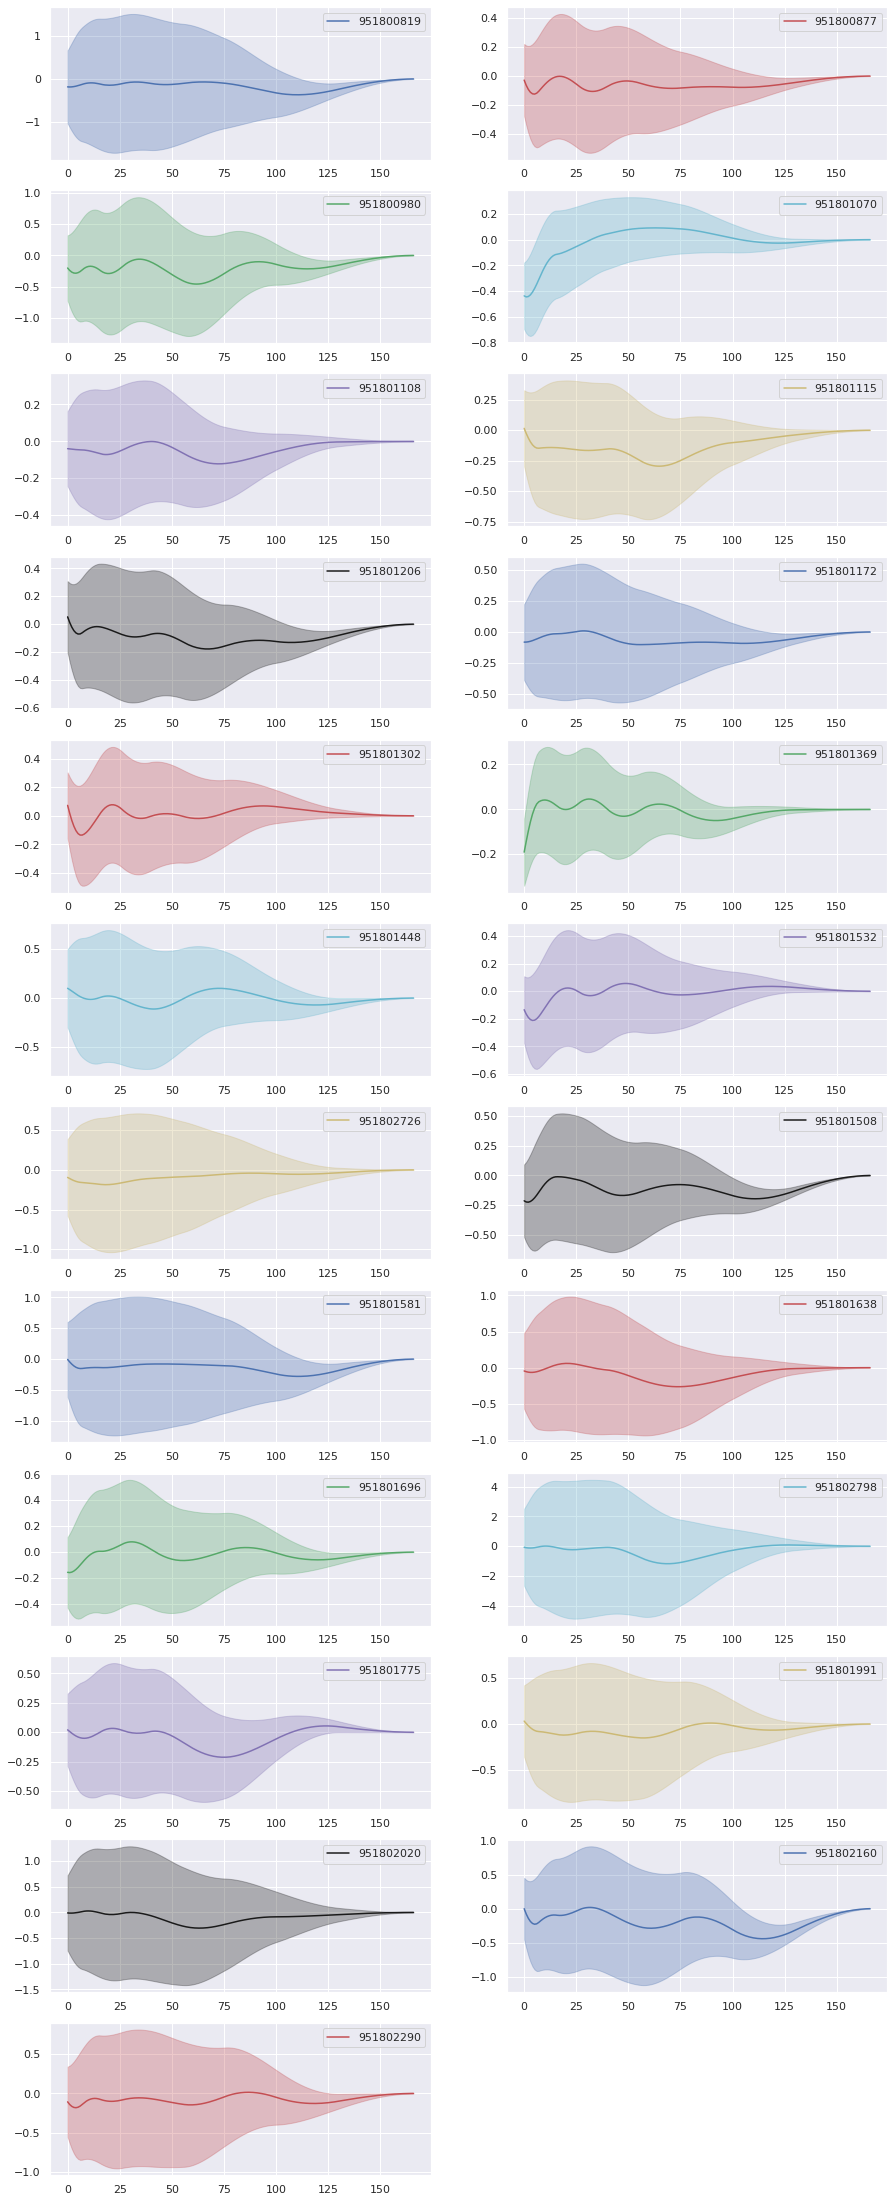

In [270]:
within_probe_name = 'probeC'
to_probe_num = 2
#####################
total = 0
totalE = 0
totalI = 0
plt.subplots(figsize=(15,50))

colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
for i in range(len(all_filter)):
    if V1._session.units.loc[idx[i]]['probe_description'] in [within_probe_name]:
        if EI_result[i][to_probe_num] == -1:
            color = colors[totalI % len(colors)]
            label = idx[i]
            y = all_filter[i][to_probe_num][0]
            x = np.arange(len(y))
            ci = all_filter[i][to_probe_num][1]
            plt.subplot(15, 2, totalI+1)
            plt.plot(x, y.squeeze(), label=label, color=color)
            plt.fill_between(x, (y-alpha*ci), (y+alpha*ci), color=color, alpha=.3)
            plt.legend()
            totalI += 1
        if EI_result[i][2] == 1:
            totalE += 1
        total += 1


total, totalE, totalI

# Look at an inhibitory neuron 951801070

In [220]:
np.where(idx==951801070)

(array([133]),)

In [247]:
print([membership_single.loc[951801070]['group_id'] for membership_single in membership])

[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]


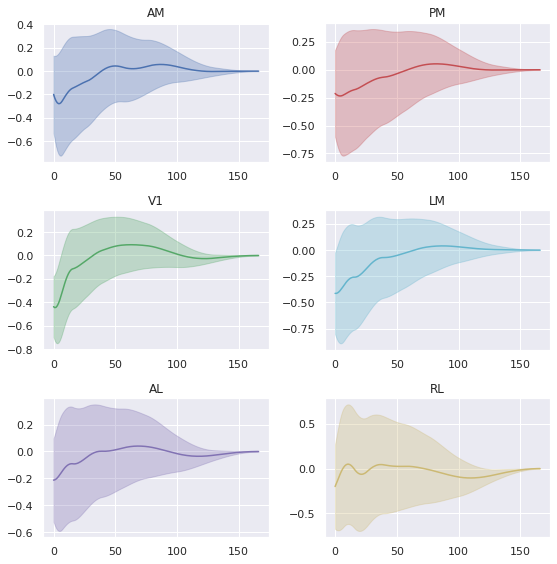

In [242]:
neuron_id = 133
plt.subplots(figsize=(8,8))

for j, input_probe in enumerate(probe_list):
    current = all_filter[neuron_id][j]
    color = colors[j % len(colors)]
    y = current[0]
    x = np.arange(len(y))
    ci = current[1]
    plt.subplot(3,2,j+1)
    plt.plot(x, y.squeeze(), color=color)
    plt.fill_between(x, (y-alpha*ci), (y+alpha*ci), color=color, alpha=.3)
    plt.title(utils.PROBE_CORRESPONDING[input_probe])
    
plt.tight_layout()

In [273]:
print(V1._session.units.loc[951801070].to_string())

waveform_halfwidth                                  0.260972
waveform_duration                                    1.00268
silhouette_score                                    0.099108
nn_hit_rate                                         0.990667
amplitude_cutoff                                    0.065373
waveform_spread                                         50.0
isi_violations                                      0.022564
presence_ratio                                          0.99
peak_channel_id                                    850116284
nn_miss_rate                                        0.003196
isolation_distance                                101.154173
waveform_PT_ratio                                   0.557222
local_index_unit                                         473
snr                                                 2.191592
waveform_velocity_below                             1.373534
d_prime                                             3.477711
firing_rate             

In [284]:
waveform_halfwidth = []
for i in range(len(all_filter)):
    waveform_halfwidth.append( V1._session.units.loc[idx[i]]['waveform_halfwidth'] )
waveform_halfwidth = np.array(waveform_halfwidth)
np.nanmean(waveform_halfwidth>0.260972)

0.11931818181818182

In [283]:
waveform_duration = []
for i in range(len(all_filter)):
    waveform_duration.append( V1._session.units.loc[idx[i]]['waveform_duration'] )
waveform_duration = np.array(waveform_duration)
np.nanmean(waveform_duration>1.00268)

0.09659090909090909

# Only fit neurons in one area

In [185]:
probe_name = 'probeC'
select_trials = V1.stationary_trial_index    # V1.running_trial_index       np.full(V1.ntrial, True)
num_basis_baseline = 30
max_iter = 5
coupling_filter_params = {'peaks_max':100, 'num':6, 'nonlinear':0.3}
######## Below doesn't need to change

probe_list = V1.selected_probes
VISUAL_AREA = ['VIS', 'VISam', 'VISpm', 'VISp', 'VISl', 'VISal', 'VISrl',
               'VISmmp', 'VISmma', 'VISli']

idx = V1._session.units[
    V1._session.units['ecephys_structure_acronym'].isin(VISUAL_AREA)].index.values

new_df = V1.spike_train.loc[idx]

all_filter_only_one_probe = []
for iunit in tqdm(range(new_df.shape[0])):
    if V1._session.units.loc[idx[iunit]]['probe_description'] in [probe_name]:
        single_spike_train = np.zeros((1000, V1.spike_train.shape[1]))
        filter_unit = []
        for itrial in range(new_df.shape[1]):
            single_spike_train[:,itrial] += new_df.iloc[iunit, itrial]
        for iprobe, probe in enumerate(probe_list):
            model = GLM.PP_GLM(dataset=V1, 
                               select_trials=select_trials, 
                               membership=membership, 
                               condition_ids=condition_ids)
            model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
            for j, input_probe in enumerate(probe_list):
    #             if i==j:
    #                 continue
                pass
                model.add_effect('coupling', probe_list[j], **coupling_filter_params)
            model.add_effect('coupling', single_spike_train, **coupling_filter_params)
    #         model.fit_time_warping_baseline(probe, verbose=False, max_iter=max_iter)
            model.fit(probe, verbose=False)
            filter_unit.append( model.get_filter(ci=True)[-1] )
        all_filter_only_one_probe.append(filter_unit)

100%|██████████████████████████████████| 352/352 [15:50<00:00,  2.70s/it]


In [192]:
alpha = 2
####################
EI_result = []

for i in range(len(all_filter_only_one_probe)):
    EI = [0]*6
    
    for j, input_probe in enumerate(probe_list):
        current = all_filter_only_one_probe[i][j]
        isE = np.any(current[0] - alpha*current[1]>0)
        isI = np.any(current[0] + alpha*current[1]<0)
        if isE and isI:
            EI[j] = 2
        elif isE and (not isI):
            EI[j] = 1
        elif (not isE) and isI:
            EI[j] = -1
        else:
            EI[j] = 0
    EI_result.append(EI)


(85, 20, 18)

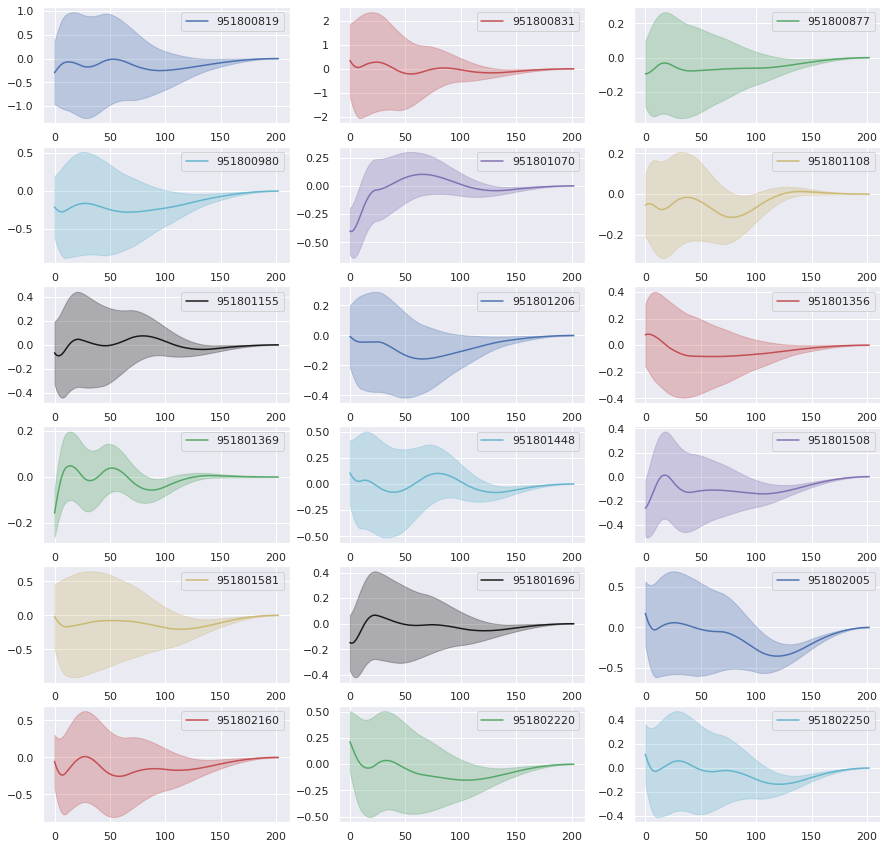

In [199]:
within_probe_name = 'probeC'
to_probe_num = 5
#####################
total = 0
totalE = 0
totalI = 0
plt.subplots(figsize=(15,15))

colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
ii = 0
for i in range(len(all_filter)):
    if V1._session.units.loc[idx[i]]['probe_description'] in [within_probe_name]:
        if EI_result[ii][2] == -1:
            color = colors[totalI % len(colors)]
            label = idx[i]
            y = all_filter_only_one_probe[ii][2][0]
            x = np.arange(len(y))
            ci = all_filter_only_one_probe[ii][2][1]
            plt.subplot(6, 3, totalI+1)
            plt.plot(x, y.squeeze(), label=label, color=color)
            plt.fill_between(x, (y-alpha*ci), (y+alpha*ci), color=color, alpha=.3)
            plt.legend()
            totalI += 1
        if EI_result[ii][2] == 1:
            totalE += 1
        total += 1
        ii += 1


total, totalE, totalI